In [1]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import os

from core.models.rbf_variance import RBF_Variance
from core.models.vae import VAE_model
from core.dataset import FilteredMNIST
from core.utils import extract_representation, plot_latent_space, plot_input_space, plot_variance_comparison, plot_geodesic

In [2]:
# MNIST Dataset transformation
mnist_transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] interval
    transforms.Lambda(lambda x: torch.flatten(x)) # Flattens the image to a 1D vector
])

# Download and load the MNIST dataset
full_train_dataset = datasets.MNIST(root='mnist_data', train=True, transform=mnist_transform, download=True)
print("Original size of the dataset: ", len(full_train_dataset))
filtered_labels = [0, 1]

print("Filtered labels: ", filtered_labels)
train_dataset = FilteredMNIST(full_train_dataset, filtered_labels)
print("New size of the dataset: ", len(train_dataset))

batch_size = 256
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)

Original size of the dataset:  60000
Filtered labels:  [0, 1]
New size of the dataset:  12665


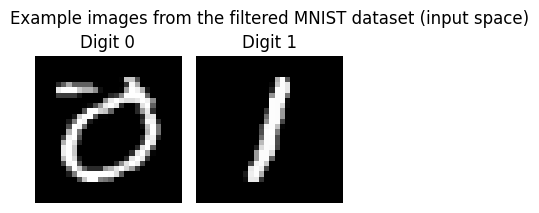

In [3]:
plot_input_space(train_loader, filtered_labels)

In [4]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct an artificial dataset
D = 28 * 28  # dimensionality of the input

# Parameters of the VAE
d = 2  # The latent space dimension
activFun = nn.LeakyReLU(0.2)
H = 128
lambda_reg = 1e-7  # For the weights of the networks
epochs = 500
learning_rate = 2e-4

In [5]:
# The model and the optimizer for the VAE
model = VAE_model(d, D, H, activFun).to(device)
optimizer_model = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_reg)

In [6]:
# if model already exists, load it
model_path = "saved_models/vae_model_mnist_01_withvar.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_mnist_01_withvar.pt


In [7]:
# Extract the latent representations for the training data
Z, labels, X_train = extract_representation(model, train_loader, device)

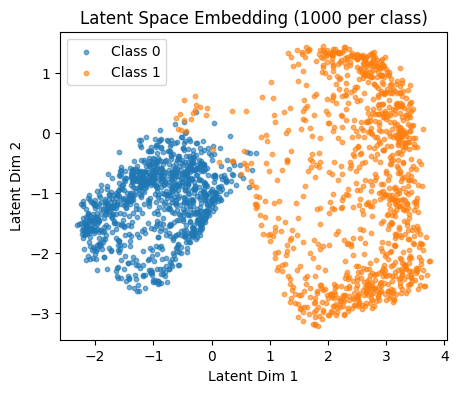

In [8]:
plot_latent_space(Z, labels)

In [9]:
K = 15  # Number of RBF centers
rbf = RBF_Variance(d=d, D=D, K=K, zeta=1e-6).to(device)
rbf.init_centers(Z, a=1.25)

rbf.load_state_dict(torch.load('saved_models/rbf_variance_01.pt'))

RBF centers initialized


<All keys matched successfully>

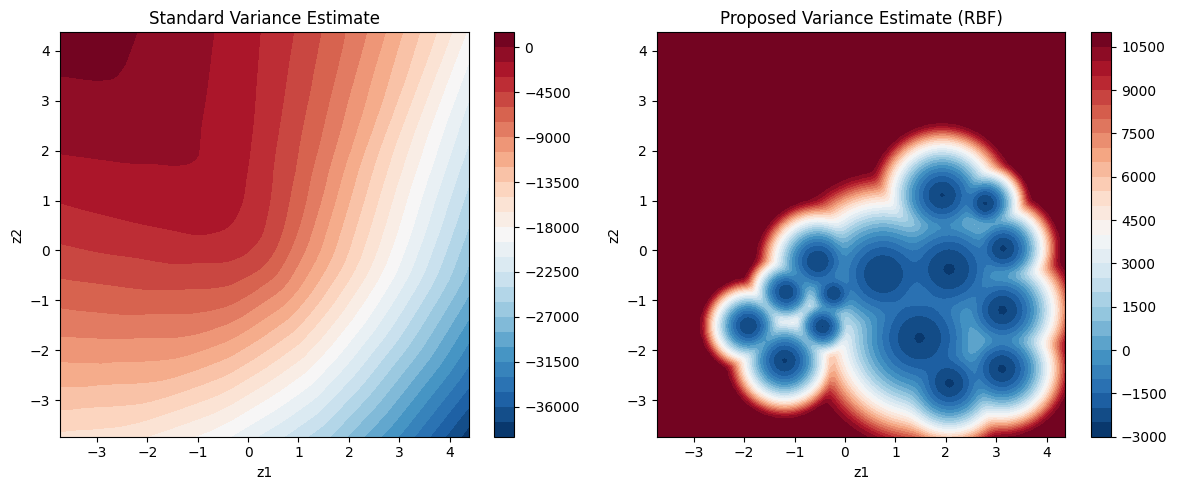

In [10]:
plot_variance_comparison(model, rbf, Z.cpu().numpy(), device)

/home/infres/court-22/miniconda3/lib/python3.12/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969118/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


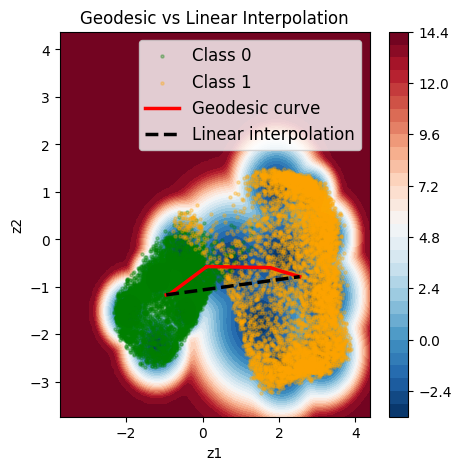

In [11]:
Z_np = Z.cpu().numpy()
labels_np = labels.cpu().numpy()

# Taking the clusters centers as the mean of the latent representations for each class
z_start = Z_np[labels_np == 0].mean(axis=0)  # center classe 0
z_end   = Z_np[labels_np == 1].mean(axis=0)  # center classe 1

plot_geodesic(model, rbf, Z_np, labels_np, z_start, z_end, device)